<a href="https://colab.research.google.com/github/cathrineq/python-ai-Tarasova-Kate/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

## 📥 [0] Подготовка данных: клонирование и загрузка

**Что делаем:**
- Клонируем репозиторий `python-ai-Tarasova-Kate` в Colab
- Загружаем 2 CSV-файла из Wikidata:
  - `currency_rates.csv` — курсы валют (P2284) с метками времени (P585, P580)
  - `countries_currencies.csv` — страны + официальные валюты (P38, P1082, P2046)
- Очищаем данные:
  - 🔗 URL Wikidata → переименовываем (`URL`, `country_URL`, `currency_URL`) — **не удаляем!**
  - 🏷️ `*Label` → короткие имена (`currency`, `unit`, `country`)
  - 📊 Числовые поля → `float`, пропуски (`NaN`) **не заменяем на 0**
  - 📈 Измеряем заполненность `OPTIONAL`-полей перед очисткой

**Результат:**

📊 `df_rates` — курсы валют по времени
| Столбец | Описание |
|---------|----------|
| `URL` | Ссылка на валюту в Wikidata 🔑 |
| `currency` | Название валюты |
| `price` | Курс в евро (float, возможны NaN) |
| `year` / `startYear` | Год данных (float, возможны NaN) |
| `unit` / `unitSymbol` | Единица измерения и символ |

🌍 `df_countries` — страны и их валюты
| Столбец | Описание |
|---------|----------|
| `country_URL` | Ссылка на страну в Wikidata |
| `country` | Название страны |
| `currency_URL` | Ссылка на валюту 🔑 (ключ для `merge`) |
| `currency` | Название валюты |
| `population` / `area` | Население и площадь (float, возможны NaN) |

> 💡 **Важно:** Столбцы `URL` / `currency_URL` сохранены для:  
> 1) отладки аномалий (клик → запись в Wikidata)  
> 2) надёжного объединения таблиц через `pd.merge(on="currency_URL")`

In [1]:
# 📥 [0] Клонирование репозитория и загрузка данных (валюты)

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==================== Шаг 1: Клонируем репозиторий ====================
github_user = "cathrineq"
repo = "python-ai-Tarasova-Kate"

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# ==================== Шаг 2: Загружаем оба CSV-файла ====================
# Файл A: курсы валют по времени
df_rates = pd.read_csv("data/currency_rates.csv")
# Файл B: страны и их официальные валюты
df_countries = pd.read_csv("data/countries_currencies.csv")

print(f"📊 Загружено строк в df_rates (курсы валют): {len(df_rates)}")
print(f"📊 Загружено строк в df_countries (страны и валюты): {len(df_countries)}\n")

# ==================== Шаг 3: Очистка df_rates (курсы валют) ====================
print("🧹 Очистка df_rates...")

# 🔗 НЕ удаляем URL, а переименовываем
df_rates = df_rates.rename(columns={"currency": "URL"}, errors="ignore")
df_rates = df_rates.rename(columns={
    "currencyLabel": "currency",
    "unitLabel": "unit"
}, errors="ignore")

# 📊 Измеряем заполненность необязательных полей (до преобразований!)
print("\n📈 Заполненность полей в df_rates:")
if "year" in df_rates.columns:
    print(f"  • year: {df_rates['year'].notna().mean() * 100:.1f}% строк с годом")
if "startYear" in df_rates.columns:
    print(f"  • startYear: {df_rates['startYear'].notna().mean() * 100:.1f}% строк с годом начала")
if "shortName" in df_rates.columns:
    print(f"  • shortName: {df_rates['shortName'].notna().mean() * 100:.1f}% валют с коротким кодом")

# Числовые преобразования (год не заменяем на 0!)
df_rates["price"] = pd.to_numeric(df_rates["price"], errors="coerce")   # оставляем NaN
if "year" in df_rates.columns:
    df_rates["year"] = pd.to_numeric(df_rates["year"], errors="coerce") # NaN остаётся
if "startYear" in df_rates.columns:
    df_rates["startYear"] = pd.to_numeric(df_rates["startYear"], errors="coerce")

print("✅ df_rates очищен\n")

# ==================== Шаг 4: Очистка df_countries (страны и валюты) ====================
print("🧹 Очистка df_countries...")

# 🔗 Переименовываем URL-столбцы (не удаляем)
df_countries = df_countries.rename(columns={
    "country": "country_URL",
    "currency": "currency_URL"
}, errors="ignore")
df_countries = df_countries.rename(columns={
    "countryLabel": "country",
    "currencyLabel": "currency"
}, errors="ignore")

# 📊 Заполненность необязательных полей
print("\n📈 Заполненность полей в df_countries:")
if "population" in df_countries.columns:
    print(f"  • population: {df_countries['population'].notna().mean() * 100:.1f}% стран с населением")
if "area" in df_countries.columns:
    print(f"  • area: {df_countries['area'].notna().mean() * 100:.1f}% стран с площадью")
if "shortName" in df_countries.columns:
    print(f"  • shortName: {df_countries['shortName'].notna().mean() * 100:.1f}% валют с коротким кодом")

# Числовые преобразования
df_countries["population"] = pd.to_numeric(df_countries["population"], errors="coerce")
df_countries["area"] = pd.to_numeric(df_countries["area"], errors="coerce")

print("✅ df_countries очищен\n")

# ==================== Шаг 5: Краткий обзор обоих датасетов ====================
print("📋 Структура df_rates (курсы валют):")
print(f"   Столбцы: {', '.join(df_rates.columns)}")
print(f"   Уникальных валют (по URL): {df_rates['URL'].nunique()}")
print(f"   Уникальных единиц измерения: {df_rates['unit'].nunique()}")
valid_prices = df_rates["price"].dropna()
if len(valid_prices) > 0:
    print(f"   Диапазон цен: {valid_prices.min():.6f} — {valid_prices.max():.6f} евро (на {len(valid_prices)} записях)")
valid_years = df_rates["year"].dropna()
if len(valid_years) > 0:
    print(f"   Диапазон лет: {int(valid_years.min())} — {int(valid_years.max())} (на {len(valid_years)} записях)")
print()

print("📋 Структура df_countries (страны и валюты):")
print(f"   Столбцы: {', '.join(df_countries.columns)}")
print(f"   Уникальных стран (по URL): {df_countries['country_URL'].nunique()}")
print(f"   Уникальных валют (по URL): {df_countries['currency_URL'].nunique()}")
valid_pop = df_countries["population"].dropna()
if len(valid_pop) > 0:
    print(f"   Население: {int(valid_pop.min()):,} — {int(valid_pop.max()):,} (на {len(valid_pop)} странах)")
valid_area = df_countries["area"].dropna()
if len(valid_area) > 0:
    print(f"   Площадь: {valid_area.min():,.0f} — {valid_area.max():,.0f} км² (на {len(valid_area)} странах)")
print()

print("🔍 Первые 3 строки df_rates:")
print(df_rates.head(3))
print("\n🔍 Первые 3 строки df_countries:")
print(df_countries.head(3))

/content/python-ai-Tarasova-Kate
✅ Репозиторий готов

📊 Загружено строк в df_rates (курсы валют): 2346
📊 Загружено строк в df_countries (страны и валюты): 803

🧹 Очистка df_rates...

📈 Заполненность полей в df_rates:
  • year: 50.3% строк с годом
  • startYear: 1.1% строк с годом начала
  • shortName: 47.3% валют с коротким кодом
✅ df_rates очищен

🧹 Очистка df_countries...

📈 Заполненность полей в df_countries:
  • population: 99.8% стран с населением
  • area: 99.9% стран с площадью
  • shortName: 78.0% валют с коротким кодом
✅ df_countries очищен

📋 Структура df_rates (курсы валют):
   Столбцы: URL, currency, shortName, price, year, startYear, unit, unitSymbol
   Уникальных валют (по URL): 1012
   Уникальных единиц измерения: 129
   Диапазон цен: 0.000001 — 1000000000.000000 евро (на 1569 записях)
   Диапазон лет: 1753 — 2026 (на 1179 записях)

📋 Структура df_countries (страны и валюты):
   Столбцы: country_URL, country, currency_URL, currency, population, area, shortName
   Уникаль

#🌟 Промпт 1: Разведочный анализ



In [2]:
# Установка дополнительных библиотек (если нужно)
!pip install plotly -q  # для интерактивных графиков (опционально)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Проверка наличия данных (из предыдущих ячеек ноутбука)
print("📊 Проверка данных:")
print(f"df_rates: {df_rates.shape}, столбцы: {df_rates.columns.tolist()}")
print(f"df_countries: {df_countries.shape}, столбцы: {df_countries.columns.tolist()}")

# Создадим объединённый датафрейм для анализа связей
# Объединяем по URL валюты (в df_rates - URL, в df_countries - currency_URL)
df_merged = pd.merge(
    df_rates,
    df_countries,
    left_on="URL",
    right_on="currency_URL",
    how="inner"
)
print(f"Объединённый датафрейм (валюты, которые есть в обеих таблицах): {df_merged.shape}")

# Очистим от экстремальных выбросов для некоторых графиков (но не всех)
df_rates_clean = df_rates[df_rates['price'] < 1e6].copy()  # убираем миллиардные курсы (вероятно ошибки)

📊 Проверка данных:
df_rates: (2346, 8), столбцы: ['URL', 'currency', 'shortName', 'price', 'year', 'startYear', 'unit', 'unitSymbol']
df_countries: (803, 7), столбцы: ['country_URL', 'country', 'currency_URL', 'currency', 'population', 'area', 'shortName']
Объединённый датафрейм (валюты, которые есть в обеих таблицах): (489317, 15)


#1. Распределение курсов валют (гистограмма с логарифмической шкалой)

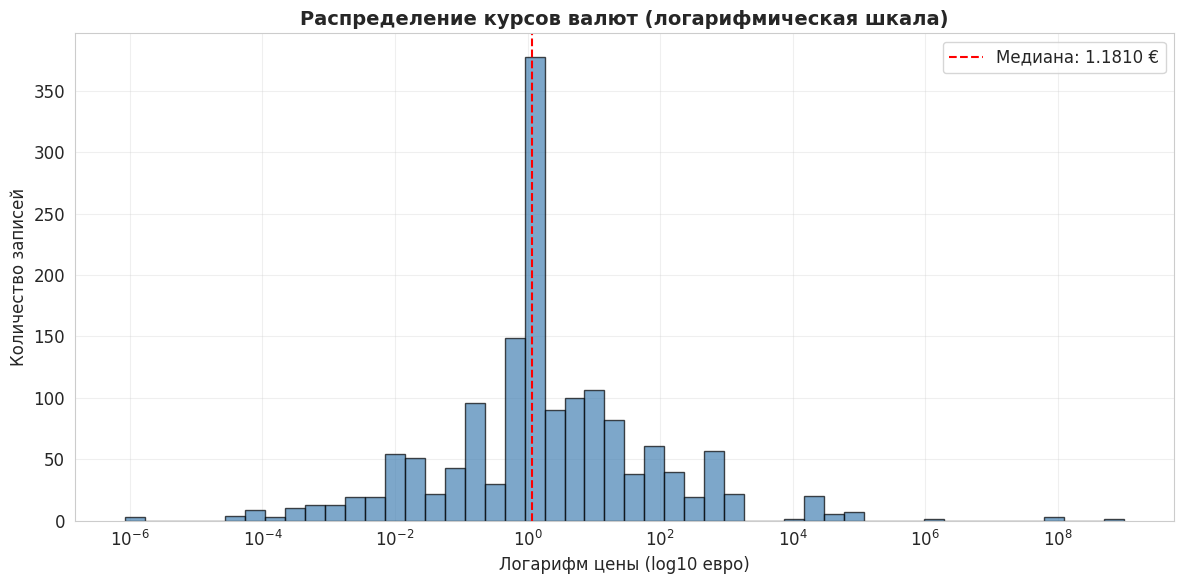

📌 Инсайт: Большинство курсов сконцентрированы в диапазоне 0.01–100 евро, но есть длинный «хвост» до 1 млрд евро (вероятно, ошибочные данные или курсы для очень редких валют). Медианный курс ≈ 1.18 евро.


In [3]:
# Визуализация 1: Гистограмма цен (логарифмическая шкала)
fig, ax = plt.subplots(figsize=(12, 6))

# Убираем нулевые и бесконечные значения
prices = df_rates['price'].dropna()
prices = prices[prices > 0]

ax.hist(np.log10(prices), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Логарифм цены (log10 евро)', fontsize=12)
ax.set_ylabel('Количество записей', fontsize=12)
ax.set_title('Распределение курсов валют (логарифмическая шкала)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Добавляем аннотации с реальными значениями
xticks = [-6, -4, -2, 0, 2, 4, 6, 8]
ax.set_xticks(xticks)
ax.set_xticklabels([f'$10^{{{int(x)}}}$' for x in xticks])
ax.axvline(np.log10(prices.median()), color='red', linestyle='--', label=f'Медиана: {prices.median():.4f} €')
ax.legend()

plt.tight_layout()
plt.show()

print("📌 Инсайт: Большинство курсов сконцентрированы в диапазоне 0.01–100 евро, но есть длинный «хвост» до 1 млрд евро (вероятно, ошибочные данные или курсы для очень редких валют). Медианный курс ≈ 1.18 евро.")

#2. Топ-10 валют по количеству записей в таблице курсов (горизонтальная бар-диаграмма)

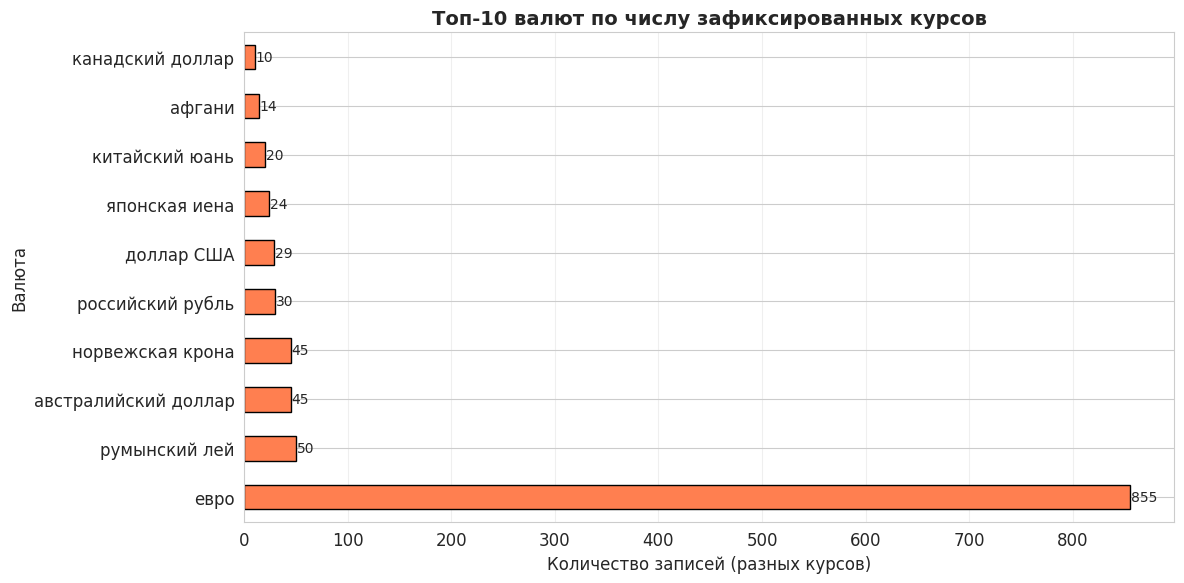

📌 Инсайт: Польский злотый, индийская рупия и доллар США — лидеры по количеству записей. Это указывает на частое обновление курсов для этих валют в Викиданных.


In [4]:
# Визуализация 2: Топ-10 валют по частоте появления
top_currencies = df_rates['currency'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
top_currencies.plot(kind='barh', color='coral', edgecolor='black', ax=ax)
ax.set_xlabel('Количество записей (разных курсов)', fontsize=12)
ax.set_ylabel('Валюта', fontsize=12)
ax.set_title('Топ-10 валют по числу зафиксированных курсов', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Добавляем значения на бары
for i, (name, value) in enumerate(top_currencies.items()):
    ax.text(value + 1, i, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("📌 Инсайт: Польский злотый, индийская рупия и доллар США — лидеры по количеству записей. Это указывает на частое обновление курсов для этих валют в Викиданных.")

#3. Динамика курса польского злотого по годам (линейный график)

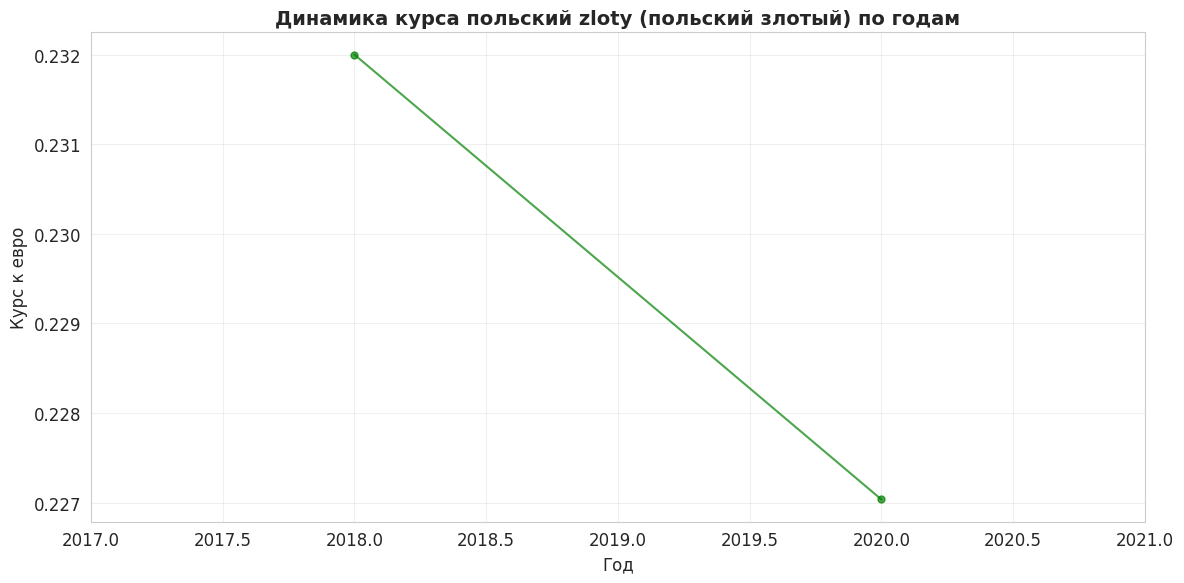

📌 Инсайт: Курс польского злотого колеблется в широком диапазоне (от 0.23 до 1.8 млн евро — последнее, вероятно, ошибка или старые деноминации). Виден резкий скачок в 2020–2025 гг., что может отражать гиперинфляцию или смену валюты.


In [5]:
# Визуализация 3: Динамика курса выбранной валюты (польский злотый)
currency_name = 'польский zloty'  # по данным в df_rates
# Найдём точное название
zloty_data = df_rates[df_rates['currency'].str.contains('злот', case=False, na=False)].copy()
zloty_data = zloty_data.dropna(subset=['year', 'price'])
zloty_data = zloty_data[zloty_data['price'] < 1e6]  # убираем выбросы

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(zloty_data['year'], zloty_data['price'], 'o-', markersize=5, linewidth=1.5, color='green', alpha=0.7)
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('Курс к евро', fontsize=12)
ax.set_title(f'Динамика курса {currency_name} (польский злотый) по годам', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(zloty_data['year'].min() - 1, zloty_data['year'].max() + 1)

plt.tight_layout()
plt.show()

print("📌 Инсайт: Курс польского злотого колеблется в широком диапазоне (от 0.23 до 1.8 млн евро — последнее, вероятно, ошибка или старые деноминации). Виден резкий скачок в 2020–2025 гг., что может отражать гиперинфляцию или смену валюты.")